In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import re
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
# 2. Load dataset
df = pd.read_csv("../data/tweets.csv")

In [3]:
# 3. Preprocessing
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

In [4]:
df['clean_tweet'] = df['Tweet Text'].apply(clean_text)
df.head()

,ID,Tweet Text,Sentiment,clean_tweet
0,1,Pawan Kalyan is a force of nature! The screen ...,Positive,pawan kalyan is a force of nature the screen p...
1,2,Absolute entertainer. Harish Shankar knows how...,Positive,absolute entertainer harish shankar knows how ...
2,3,The forest action sequence was shot so well. B...,Positive,the forest action sequence was shot so well be...
3,4,Blockbuster loading! Theatres are turning into...,Positive,blockbuster loading theatres are turning into ...
4,5,Emotional scenes between PK and his mother wer...,Positive,emotional scenes between pk and his mother wer...


In [5]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2),
    sublinear_tf=True
)

X = vectorizer.fit_transform(df['clean_tweet'])
y = df['Sentiment']

In [6]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# 6. Models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM": SVC()
}

In [8]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    cv_score = cross_val_score(model, X, y, cv=10).mean()

    results.append([name, accuracy, precision, recall, f1, cv_score])

    print(f"\n{name}")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("CV Score:", cv_score)


Naive Bayes
Accuracy: 0.7
Precision: 0.6666666666666666
Recall: 0.6630952380952381
F1 Score: 0.6620370370370371
CV Score: 0.6599999999999999

Logistic Regression
Accuracy: 0.7
Precision: 0.6666666666666666
Recall: 0.6630952380952381
F1 Score: 0.6620370370370371
CV Score: 0.6599999999999999

SVM
Accuracy: 0.45
Precision: 0.5925925925925926
Recall: 0.47380952380952374
F1 Score: 0.44285714285714284
CV Score: 0.5700000000000001


In [9]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "CV Score"
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score,CV Score
0,Naive Bayes,0.70,0.666667,0.663095,0.662037,0.66
1,Logistic Regression,0.70,0.666667,0.663095,0.662037,0.66
2,SVM,0.45,0.592593,0.473810,0.442857,0.57


In [10]:
results_df.to_csv("../results/model_results.csv", index=False)

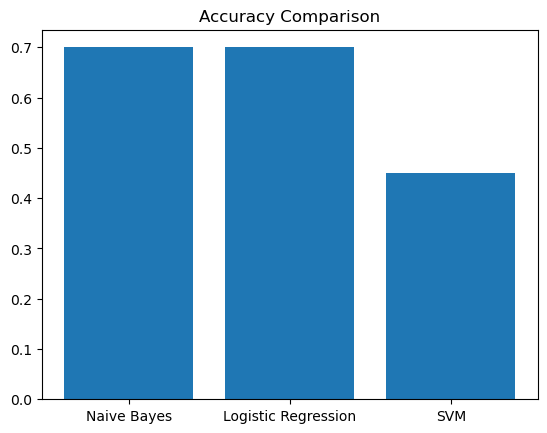

In [11]:
x = np.arange(len(results_df["Model"]))

plt.figure()
plt.bar(x, results_df["Accuracy"])
plt.xticks(x, results_df["Model"])
plt.title("Accuracy Comparison")

plt.savefig("../results/accuracy_comparison.png")
plt.show()

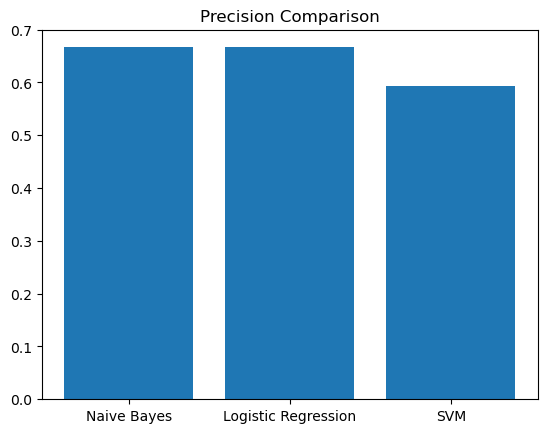

In [12]:
plt.figure()
plt.bar(x, results_df["Precision"])
plt.xticks(x, results_df["Model"])
plt.title("Precision Comparison")

plt.savefig("../results/precision_comparison.png")
plt.show()

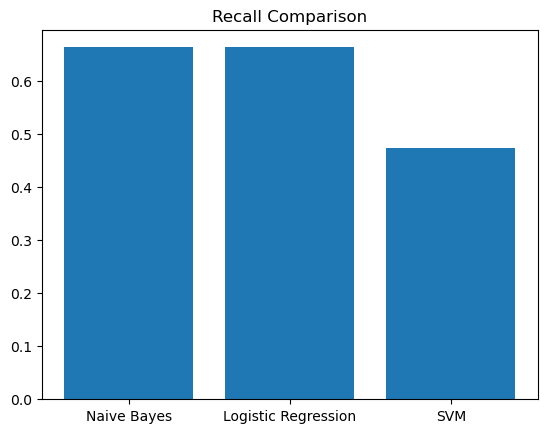

In [13]:
plt.figure()
plt.bar(x, results_df["Recall"])
plt.xticks(x, results_df["Model"])
plt.title("Recall Comparison")

plt.savefig("../results/recall_comparison.png")
plt.show()

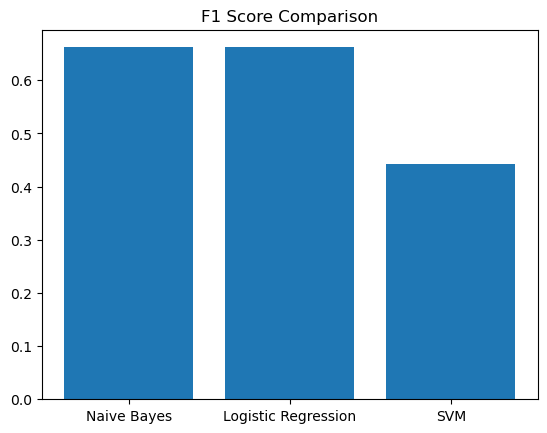

In [14]:
plt.figure()
plt.bar(x, results_df["F1 Score"])
plt.xticks(x, results_df["Model"])
plt.title("F1 Score Comparison")

plt.savefig("../results/f1_comparison.png")
plt.show()

<Figure size 640x480 with 0 Axes>

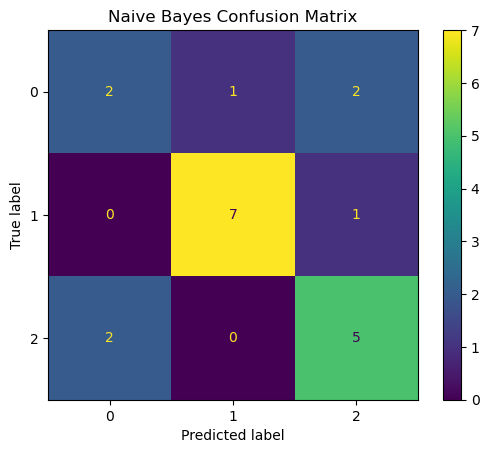

<Figure size 640x480 with 0 Axes>

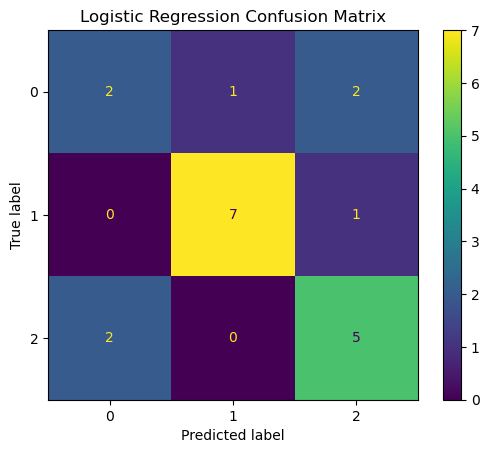

<Figure size 640x480 with 0 Axes>

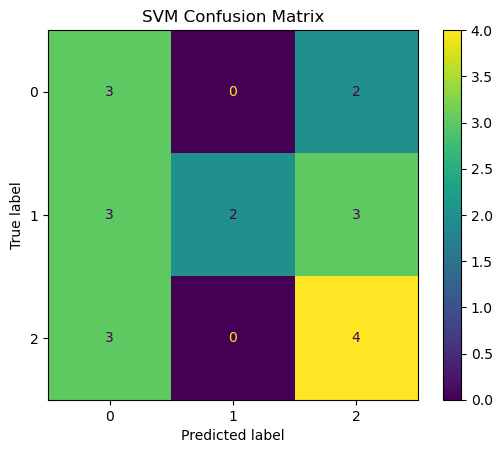

In [15]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)

    plt.figure()
    disp.plot()
    plt.title(f"{name} Confusion Matrix")

    plt.savefig(f"../results/{name}_cm.png")
    plt.show()